# HoTHP vs RoTHP — Extrapolação em Horizonte

**Como rodar no Colab:** Runtime → Change runtime type → T4 GPU

---

## O que este notebook prova?

Treinamos dois modelos (`HoTHP` e `RoTHP`) em sequências **curtas** (≤50 eventos),  
e depois testamos os dois em sequências **muito mais longas** (até 500 eventos).  
Isso é chamado de **extrapolação fora da distribuição de treino (OOD)**.

A hipótese central é:
> Em processos de **decaimento rápido**, o HoTHP degrada muito menos do que o RoTHP  
> ao extrapolar para horizontes muito maiores do que o visto no treino.

### Por que isso importa?
- O RoTHP usa embeddings rotativos que interpolam bem, mas não garantem comportamento estável além do comprimento de treino.
- O HoTHP usa um kernel hiperbólico **monotonicamente decrescente** — matematicamente adequado para capturar influência temporal que se dissipa rapidamente.

**Tempo estimado:** ~25–35 min numa GPU T4 do Colab.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 1 — Instalação
# Baixa o repositório do GitHub e instala a única dependência extra.
# Basta rodar uma vez por sessão do Colab.
# ─────────────────────────────────────────────────────────────────────────────

import os

# Clona o repositório apenas se ainda não existir na sessão
if not os.path.exists('ufc-easytpp'):
    !git clone https://github.com/hugoramos/ufc-easytpp.git

# omegaconf é usado pelo EasyTPP para carregar configurações YAML
!pip install omegaconf -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 2 — Imports e configurações globais
# Aqui definimos todos os parâmetros do experimento em um só lugar.
# ─────────────────────────────────────────────────────────────────────────────

import os, sys, math, random, hashlib, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from scipy import stats

# ── Parâmetros do experimento ──────────────────────────────────────────────

TRAIN_LEN      = 50          # comprimento máximo das sequências de treino (eventos)
EXTRAP_FACTORS = [2, 5, 10]  # fatores de extrapolação: 100 / 250 / 500 eventos
N_SEEDS        = 20          # quantas rodadas com sementes diferentes (para robustez)
EPOCHS         = 500         # máximo de épocas de treino
PATIENCE       = 30          # para early stopping: para se não melhorar por 30 épocas
BASE_SEED      = 42          # semente base para reprodutibilidade
NUM_TYPES      = 2           # número de tipos de eventos (ex: cliques tipo 0 e tipo 1)
PAD_ID         = NUM_TYPES   # índice usado para preencher (padding) sequências menores

# ── Definição dos dois processos de Hawkes ─────────────────────────────────
# Um processo de Hawkes simula eventos onde cada evento passado influencia
# a probabilidade de novos eventos futuros, com decaimento exponencial.
#
# mu    = taxa base de chegada de eventos (sem influência do histórico)
# alpha = intensidade com que cada evento passado dispara novos eventos
# beta  = quão rápido essa influência decai no tempo

# Processo de DECAIMENTO LENTO (beta pequeno = influência dura muito tempo)
# Aqui esperamos que ambos os modelos se comportem de forma similar.
PROC_SLOW = dict(
    mu    = np.array([0.3, 0.3]),
    alpha = np.array([[0.008, 0.006], [0.006, 0.008]]),
    beta  = 0.02,
    label = 'Decaimento LENTO  (β_norm ≈ 0.025)',
)

# Processo de DECAIMENTO RÁPIDO (beta grande = influência some rapidamente)
# Aqui o HoTHP deve CLARAMENTE superar o RoTHP na extrapolação.
PROC_FAST = dict(
    mu    = np.array([0.4, 0.4]),
    alpha = np.array([[0.12, 0.08], [0.08, 0.12]]),
    beta  = 0.50,
    label = 'Decaimento RÁPIDO (β_norm ≈ 0.40)',
)

# Lista dos dois processos para iterar depois
PROCESSES = [('slow', PROC_SLOW), ('fast', PROC_FAST)]

# Cores dos modelos nos gráficos
COR_ROTHP = '#4C72B0'   # azul para RoTHP
COR_HOTHP = '#C44E52'   # vermelho para HoTHP

# ── Funções auxiliares de reprodutibilidade ────────────────────────────────

def set_seed(seed):
    """Fixa todas as sementes aleatórias para garantir reprodutibilidade."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

def run_seed(*parts):
    """Gera uma semente diferente para cada combinação de argumentos.
    Evita usar a mesma semente para treino de modelos diferentes."""
    key = '::'.join(map(str, parts))
    return (BASE_SEED + int(hashlib.sha256(key.encode()).hexdigest()[:8], 16)) % (2**31)

set_seed(BASE_SEED)

# ── Configuração do dispositivo (GPU ou CPU) ───────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# AMP = Automatic Mixed Precision: acelera o treino na GPU usando float16
USE_AMP = device.type == 'cuda'
if USE_AMP:
    try:
        _autocast = lambda: torch.amp.autocast(device_type='cuda')
        _Scaler   = torch.amp.GradScaler
    except AttributeError:
        _autocast = torch.cuda.amp.autocast
        _Scaler   = torch.cuda.amp.GradScaler
else:
    _autocast = contextlib.nullcontext
    _Scaler   = None

# ── Carrega os modelos do repositório ─────────────────────────────────────
sys.path.insert(0, os.path.abspath('ufc-easytpp'))

import easy_tpp.model.torch_model.torch_baselayer as baselayer

# Sobrescreve a função de atenção interna para uma versão mais estável numericamente
# def _attention(query, key, value, mask=None, dropout=None):
#     """Atenção multi-cabeça padrão (scaled dot-product)."""
#     d_k = query.size(-1)
#     scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
#     if mask is not None:
#         if mask.dim() == 3:
#             mask = mask.unsqueeze(1)
#         scores = scores.masked_fill(mask > 0, -1e4)
#     p = torch.softmax(scores, dim=-1)
#     if dropout is not None:
#         p = dropout(p)
#     return torch.matmul(p, value), p

# baselayer.attention = _attention

import easy_tpp.model.torch_model.torch_rothp as rothp_module
# rothp_module.attention = _attention

from easy_tpp.config_factory.model_config import ModelConfig
from easy_tpp.model.torch_model.torch_rothp import RoTHP
from easy_tpp.model.torch_model.torch_hothp import HoTHP

print(f'Dispositivo: {device}  |  AMP (mixed precision): {USE_AMP}')
print(f'Treino: sequências com ≤ {TRAIN_LEN} eventos')
print(f'Teste OOD: {[TRAIN_LEN * f for f in EXTRAP_FACTORS]} eventos ({EXTRAP_FACTORS}× o treino)')

Dispositivo: cpu  |  AMP (mixed precision): False
Treino: sequências com ≤ 50 eventos
Teste OOD: [100, 250, 500] eventos ([2, 5, 10]× o treino)


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 3 — Geração dos dados sintéticos
# Simulamos processos de Hawkes multivariados para criar nossos datasets.
# ─────────────────────────────────────────────────────────────────────────────

def simulate_hawkes(rng, mu, alpha, beta, horizon, min_ev, max_ev):
    """
    Simula um processo de Hawkes multivariado usando o algoritmo de thinning.

    Ideia: gera candidatos de tempo com taxa máxima (Poisson),
    depois aceita ou rejeita cada candidato conforme a taxa real no momento.

    Parâmetros:
      rng     : gerador de números aleatórios numpy
      mu      : taxa base de cada tipo de evento
      alpha   : matriz de excitação (como cada evento estimula outros)
      beta    : taxa de decaimento exponencial da influência
      horizon : tempo máximo de simulação
      min_ev  : mínimo de eventos para aceitar a sequência
      max_ev  : máximo de eventos retornados

    Retorna:
      lista de tuplas (tempo, tipo_do_evento)
    """
    for _ in range(100):  # tenta até 100 vezes para garantir min_ev eventos
        events, t = [], 0.0
        while t < horizon and len(events) < max_ev:
            # Calcula a taxa atual somando contribuições de todos os eventos passados
            lam = mu.copy()
            for ti, ki in events:
                lam += alpha[:, ki] * np.exp(-beta * (t - ti))
            lam_bar = float(lam.sum())
            if lam_bar < 1e-9:
                break
            # Amostra o próximo tempo candidato
            t += rng.exponential(1.0 / lam_bar)
            if t >= horizon:
                break
            # Recalcula a taxa real no tempo candidato
            cand = mu.copy()
            for ti, ki in events:
                cand += alpha[:, ki] * np.exp(-beta * (t - ti))
            # Aceita ou rejeita o candidato (passo de thinning)
            if rng.uniform() <= cand.sum() / lam_bar:
                probs = cand / cand.sum()
                events.append((t, int(rng.choice(len(mu), p=probs))))
        if len(events) >= min_ev:
            return events[:max_ev]
    return events[:max_ev]


def to_tensors(seqs):
    """
    Converte uma lista de sequências de eventos em tensores PyTorch.
    Aplica normalização por sequência: divide os tempos pelo gap médio,
    para que o intervalo médio entre eventos seja ~1 (mesma escala para todos).
    O gap é a média dos deltas.. assim, os tempos ficam próximos, independente da escala original de tempo
    """
    out = []
    for seq in seqs:
        seq = sorted(seq, key=lambda x: x[0])         # garante ordem temporal
        t = torch.tensor([x[0] for x in seq], dtype=torch.float32)  # tempos absolutos
        k = torch.tensor([x[1] for x in seq], dtype=torch.long)     # tipos
        d = torch.zeros_like(t)                        # gaps (diferenças entre tempos)
        d[1:] = t[1:] - t[:-1]
        mg = d[1:].mean().clamp(min=1e-6)              # gap médio (evita divisão por zero)
        t = (t - t[0]) / mg                            # normaliza tempos
        d = d / mg                                     # normaliza gaps
        out.append({'time_seqs': t, 'time_delta_seqs': d, 'type_seqs': k})
    return out


def collate(batch):
    """
    Função de collation: agrupa sequências de tamanhos variados em batches.
    Adiciona padding para igualar o comprimento de todas as sequências do batch.
    Cria a máscara causal (cada evento só pode ver eventos anteriores).
    """
    B = len(batch)
    L = max(len(x['time_seqs']) for x in batch)  # comprimento da maior sequência no batch

    # Inicializa tensores com zeros ou padding
    t_pad  = torch.zeros(B, L)
    d_pad  = torch.zeros(B, L)
    k_pad  = torch.full((B, L), PAD_ID, dtype=torch.long) # PAD_ID é o len(k) + 1, que é um numero impossível
    npm    = torch.zeros(B, L)   # máscara de posições reais (não-padding mask)

    # Máscara causal: impede que o modelo olhe para frente no tempo
    causal = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
    attn   = torch.ones(B, L, L, dtype=torch.bool)

    for i, item in enumerate(batch):
        sl = len(item['time_seqs']) # sequence length.. tamanho da sequencia
        t_pad[i, :sl] = item['time_seqs']
        d_pad[i, :sl] = item['time_delta_seqs']
        k_pad[i, :sl] = item['type_seqs']
        npm[i, :sl]   = 1.0  # marca posições reais (non-padding mask)
        m = causal.clone()
        m[:, sl:] = True     # mascara posições de padding nas colunas
        m[sl:, :] = True # nas linhas
        attn[i] = m

    return t_pad, d_pad, k_pad, npm, attn


def make_loader(data, bs, shuffle=False, seed=None):
    """Cria um DataLoader PyTorch a partir de uma lista de sequências."""
    g = None
    if shuffle and seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    return DataLoader(data, batch_size=bs, shuffle=shuffle,
                      collate_fn=collate, generator=g)


# ── Gera todos os datasets ─────────────────────────────────────────────────
print('Gerando dados sintéticos...')
rng = np.random.default_rng(run_seed('main', 'data'))
datasets = {}

for pname, proc in PROCESSES: # process names... slow e fast
    mu, alpha, beta = proc['mu'], proc['alpha'], proc['beta']

    raw = {
        # Dados de TREINO: sequências curtas (até TRAIN_LEN eventos)
        'train': [simulate_hawkes(rng, mu, alpha, beta, 50.0, 10, TRAIN_LEN)
                  for _ in range(500)],
        # Dados de VALIDAÇÃO: mesma distribuição do treino
        'val':   [simulate_hawkes(rng, mu, alpha, beta, 50.0, 10, TRAIN_LEN)
                  for _ in range(150)],
        # Dados de TESTE IN-DISTRIBUTION: sequências do mesmo tamanho do treino
        'short': [simulate_hawkes(rng, mu, alpha, beta, 50.0, 10, TRAIN_LEN)
                  for _ in range(200)],
    }

    # Dados de TESTE OOD: sequências muito mais longas do que o treino!
    for f in EXTRAP_FACTORS:
        raw[f'extrap_{f}x'] = [
            simulate_hawkes(rng, mu, alpha, beta,
                            50.0 * f,           # horizonte de tempo maior
                            TRAIN_LEN + 5,      # exige ao menos TRAIN_LEN+5 eventos
                            TRAIN_LEN * f)      # e limita a TRAIN_LEN*f eventos
            for _ in range(200)
        ]

    datasets[pname] = {k: to_tensors(v) for k, v in raw.items()}

    # Mede o β_normalizado real (beta * gap_médio) para informar nos gráficos..  βnorm = β×Δtˉ
    # Como normalizamos os dados, precisamos noramlizar beta
    # mu e alpha não precisam ser normalizados pois são intensidades e não taxas, não entram em nenhum expoente
    gaps = []
    for seq in raw['train']:
        ts = sorted([t for t, _ in seq])
        gaps.extend([ts[i] - ts[i-1] for i in range(1, len(ts))])
    mg  = np.mean(gaps)
    bn  = beta * mg
    infl = math.exp(-bn * (TRAIN_LEN * max(EXTRAP_FACTORS) - 1))
    print(f'  {pname:4s}  beta={beta:.2f}  gap_médio={mg:.3f}  '
          f'β_norm={bn:.4f}  influência@10x={infl:.4f}')

print()
print('Fração de eventos OOD (posições ≥ TRAIN_LEN nos dados de teste extrapolados):')
for f in EXTRAP_FACTORS:
    seqs  = datasets['slow'][f'extrap_{f}x']
    total = sum(len(s['time_seqs']) for s in seqs)
    ood   = sum(max(0, len(s['time_seqs']) - TRAIN_LEN) for s in seqs)
    print(f'  {f}×: {100*ood/total:.0f}% dos eventos estão além do treino (OOD)')

Gerando dados sintéticos...
  slow  beta=0.02  gap_médio=1.245  β_norm=0.0249  influência@10x=0.0000
  fast  beta=0.50  gap_médio=0.776  β_norm=0.3879  influência@10x=0.0000

Fração de eventos OOD (posições ≥ TRAIN_LEN nos dados de teste extrapolados):
  2×: 45% dos eventos estão além do treino (OOD)
  5×: 80% dos eventos estão além do treino (OOD)
  10×: 90% dos eventos estão além do treino (OOD)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 4 — Configuração dos modelos e funções de treino/avaliação
# ─────────────────────────────────────────────────────────────────────────────

# Configuração compartilhada entre RoTHP e HoTHP
# (mesma arquitetura para comparação justa: hidden_size, num_layers, num_heads)
config = ModelConfig(**{
    'hidden_size':   32,   # dimensão oculta das camadas de atenção
    'num_layers':    2,    # número de camadas Transformer
    'num_heads':     2,    # número de cabeças de atenção (multi-head)
    'dropout_rate':  0.1,  # dropout para regularização
    'num_event_types':     NUM_TYPES,
    'num_event_types_pad': NUM_TYPES + 1,
    'event_pad_index':     PAD_ID,
    'time_emb_size': 32,
    'use_ln':        True, # Layer Normalization
    'gpu': 0 if torch.cuda.is_available() else -1,
    'model_id': 'Simplificado',
    # Configurações de amostragem para inferência (não usadas neste experimento)
    'thinning': {'num_sample': 1, 'num_exp': 500, 'over_sample_rate': 5.0,
                 'patience_counter': 5, 'num_samples_boundary': 5,
                 'dtime_max': 5.0, 'num_step_gen': 1},
    'loss_integral_num_sample_per_step': 20,
    'use_mc_samples': False,
})


def eval_nll(model, dl):
    """
    Avalia a NLL (Negative Log-Likelihood) do modelo em todos os eventos.
    NLL menor = modelo melhor (mais provável que os dados reais).
    """
    model.eval()
    total_l = total_n = 0
    with torch.no_grad():
        for batch in dl:
            batch = [t.to(device) for t in batch]
            with _autocast():
                l, n = model.loglike_loss(batch)
            total_l += l.item()
            total_n += n
    return total_l / (total_n + 1e-9)


def eval_ood_nll(model, dl):
    """
    Avalia a NLL APENAS para eventos em posições ≥ TRAIN_LEN.
    Esses são os eventos OOD (fora da distribuição de treino).
    Assim medimos especificamente a capacidade de extrapolação.
    """
    model.eval()
    total_l = total_n = 0
    with torch.no_grad():
        for batch in dl:
            t, d, k, npm, attn = [x.to(device) for x in batch]
            # Zera a máscara nas posições IN-DISTRIBUTION (mantém só OOD)
            mask = npm.clone()
            mask[:, :TRAIN_LEN] = 0.0
            if mask.sum() == 0:
                continue  # batch sem eventos OOD, pula
            with _autocast():
                l, n = model.loglike_loss([t, d, k, mask, attn])
            total_l += l.item()
            total_n += n
    return total_l / (total_n + 1e-9)


def train_model(cls, train_dl, val_dl, lr, base_seed):
    """
    Treina o modelo com early stopping baseado na perda de validação.

    cls       : classe do modelo (RoTHP ou HoTHP)
    train_dl  : DataLoader de treino
    val_dl    : DataLoader de validação
    lr        : learning rate
    base_seed : semente para inicialização dos pesos

    Retorna: (modelo treinado, melhor NLL de validação)
    """
    set_seed(base_seed)
    m = cls(config).to(device)

    # AdamW: variante do Adam com weight decay para regularização
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)

    # Reduz o lr quando a validação para de melhorar (factor=0.5 = divide por 2)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=10, min_lr=1e-5)

    # Scaler para mixed precision (só na GPU)
    scaler = _Scaler(enabled=True) if USE_AMP else None

    best_val  = float('inf')
    best_state = None
    no_imp = 0  # contador de épocas sem melhora

    for ep in range(EPOCHS):
        # ── Fase de treino ──
        m.train()
        for batch in train_dl:
            batch = [t.to(device) for t in batch]
            opt.zero_grad()
            with _autocast():
                l, n = m.loglike_loss(batch)
                nll  = l / (n + 1e-9)  # NLL média por evento
            if not torch.isnan(nll):
                if scaler:
                    scaler.scale(nll).backward()
                    scaler.unscale_(opt)
                    torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)  # evita explosão do gradiente
                    scaler.step(opt)
                    scaler.update()
                else:
                    nll.backward()
                    torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                    opt.step()

        # ── Fase de validação ──
        v = eval_nll(m, val_dl)
        sched.step(v)

        if v < best_val - 1e-4:  # melhora significativa
            best_val   = v
            best_state = {k: v2.cpu().clone() for k, v2 in m.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        # Early stopping: para de treinar se não melhorou por PATIENCE épocas
        if no_imp >= PATIENCE:
            break

    # Restaura o melhor modelo visto durante o treino
    m.load_state_dict(best_state)
    return m, best_val


print('Funções de treino e avaliação prontas.')

Funções de treino e avaliação prontas.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 5 — Execução do experimento principal
# Para cada processo (lento, rápido) e cada semente:
#   1. Treina RoTHP e HoTHP nas sequências curtas
#   2. Avalia ambos em sequências in-distribution e OOD
#   3. Guarda os resultados
#
# Esta é a célula mais demorada (~25-35 min no Colab com GPU T4)
# ─────────────────────────────────────────────────────────────────────────────

seeds   = [BASE_SEED + i * 100 for i in range(N_SEEDS)]
results = []  # lista que vai acumular todos os resultados

for pname, proc in PROCESSES:
    print(f'\n{"="*55}')
    print(f'  Processo: {proc["label"]}')
    print(f'{"="*55}')

    # DataLoaders de avaliação (criados uma vez por processo)
    val_dl   = make_loader(datasets[pname]['val'],   64)
    short_dl = make_loader(datasets[pname]['short'], 64)
    ext_dls  = {f: make_loader(datasets[pname][f'extrap_{f}x'], 16)
                for f in EXTRAP_FACTORS}

    for seed_idx, seed in enumerate(seeds):
        print(f'  Semente {seed_idx+1}/{N_SEEDS}', end='  ')

        # DataLoader de treino (embaralhado com semente específica)
        train_dl = make_loader(datasets[pname]['train'], 64,
                               shuffle=True, seed=run_seed(pname, seed))

        # Treina RoTHP
        rothp, rv = train_model(
            RoTHP, train_dl, val_dl,
            lr=1e-3,
            base_seed=run_seed(pname, 'rothp', seed)
        )

        # Treina HoTHP (lr menor pois o kernel hiperbólico é mais sensível)
        hothp, hv = train_model(
            HoTHP, train_dl, val_dl,
            lr=5e-4,
            base_seed=run_seed(pname, 'hothp', seed)
        )

        # NLL in-distribution (sequências do mesmo comprimento do treino)
        r_short = eval_nll(rothp, short_dl)
        h_short = eval_nll(hothp, short_dl)
        print(f'val NLL: RoTHP={rv:.4f}  HoTHP={hv:.4f}')

        # NLL OOD para cada fator de extrapolação
        for f in EXTRAP_FACTORS:
            r_ood = eval_ood_nll(rothp, ext_dls[f])  # NLL OOD do RoTHP
            h_ood = eval_ood_nll(hothp, ext_dls[f])  # NLL OOD do HoTHP
            results.append(dict(
                proc    = pname,
                seed    = seed,
                factor  = f,
                r_short = r_short,   # NLL RoTHP na distribuição de treino
                h_short = h_short,   # NLL HoTHP na distribuição de treino
                r_ood   = r_ood,     # NLL RoTHP nos dados OOD
                h_ood   = h_ood,     # NLL HoTHP nos dados OOD
                r_val   = rv,        # NLL de validação do RoTHP (diagnóstico de convergência)
                h_val   = hv,        # NLL de validação do HoTHP (diagnóstico de convergência)
                # ΔNLL = NLL_OOD - NLL_curto: quanto o modelo piorou ao extrapolar
                r_deg   = r_ood - r_short,
                h_deg   = h_ood - h_short,
                # vantagem = ΔNLL_RoTHP - ΔNLL_HoTHP: positivo → HoTHP melhor
                adv     = r_ood - h_ood,
            ))

# Converte para DataFrame para facilitar análise
df = pd.DataFrame(results)
print('\nExperimento concluído! Rodando gráficos...')


  Processo: Decaimento LENTO  (β_norm ≈ 0.025)
  Semente 1/5  val NLL: RoTHP=1.6808  HoTHP=1.6842
  Semente 2/5  val NLL: RoTHP=1.6804  HoTHP=1.7149
  Semente 3/5  val NLL: RoTHP=1.6806  HoTHP=1.6938
  Semente 4/5  val NLL: RoTHP=1.6815  HoTHP=1.6851
  Semente 5/5  val NLL: RoTHP=1.6818  HoTHP=1.6878

  Processo: Decaimento RÁPIDO (β_norm ≈ 0.40)
  Semente 1/5  val NLL: RoTHP=1.6734  HoTHP=1.6876
  Semente 2/5  val NLL: RoTHP=1.6798  HoTHP=1.6882
  Semente 3/5  val NLL: RoTHP=1.6771  HoTHP=1.6879
  Semente 4/5  val NLL: RoTHP=1.6766  HoTHP=1.7144
  Semente 5/5  val NLL: RoTHP=1.6783  HoTHP=1.6982

Experimento concluído! Rodando gráficos...


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 6 — Diagnóstico: NLL de validação por semente
#
# Objetivo: verificar se a alta variância do RoTHP no processo rápido
# é causada por seeds que simplesmente não convergiram (problema de
# otimização, não de extrapolação).
#
# Se algumas seeds do RoTHP tiverem NLL de validação muito acima das outras,
# o problema é CONVERGÊNCIA, não extrapolação — e precisamos filtrar essas
# seeds antes de tirar conclusões sobre capacidade de extrapolação.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.patches as mpatches

# NLL de validação por semente (r_val e h_val são iguais para todos os fatores
# de uma mesma seed, então basta pegar uma linha por (proc, seed))
val_df = df.drop_duplicates(['proc', 'seed'])[
    ['proc', 'seed', 'r_val', 'h_val']
].copy().reset_index(drop=True)

# ── Gráfico: NLL de validação por semente ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NLL de Validação por Semente — Diagnóstico de Convergência',
             fontsize=13, fontweight='bold')

CONV_THRESHOLDS = {}  # guarda o threshold calculado por processo

for ax, (pname, proc) in zip(axes, PROCESSES):
    sub = val_df[val_df['proc'] == pname].reset_index(drop=True)
    x   = np.arange(len(sub))

    ax.scatter(x - 0.12, sub['r_val'], color=COR_ROTHP, s=90, zorder=3,
               label='RoTHP', edgecolors='white', linewidths=0.5)
    ax.scatter(x + 0.12, sub['h_val'], color=COR_HOTHP, s=90, zorder=3,
               label='HoTHP', edgecolors='white', linewidths=0.5)

    # Threshold automático: μ + 2σ da NLL de validação do RoTHP
    r_mean = sub['r_val'].mean()
    r_std  = sub['r_val'].std()
    thresh = r_mean + 2.0 * r_std
    CONV_THRESHOLDS[pname] = thresh

    ax.axhline(thresh, color='darkorange', ls='--', lw=1.8,
               label=f'Threshold μ+2σ = {thresh:.3f}')

    ax.set_title(proc['label'], fontsize=12)
    ax.set_xlabel('Índice da semente')
    ax.set_ylabel('NLL de validação')
    ax.set_xticks(x)
    ax.set_xticklabels([f's{i}' for i in range(len(sub))], fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('HoTHP_Diagnostico_Convergencia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Diagnóstico salvo em: HoTHP_Diagnostico_Convergencia.png')

# ── Define df_conv: apenas seeds que convergiram ──────────────────────────
print('\n── Análise de Convergência ──')
conv_parts = []
for pname, proc in PROCESSES:
    sub    = val_df[val_df['proc'] == pname]
    thresh = CONV_THRESHOLDS[pname]
    bad    = sub[sub['r_val'] >= thresh]['seed'].values
    good   = sub[sub['r_val'] <  thresh]['seed'].values
    print(f'\n{proc["label"]}')
    print(f'  Threshold (μ+2σ): {thresh:.4f}')
    print(f'  Seeds convergidas: {len(good)}/{len(sub)}')
    if len(bad) > 0:
        print(f'  Seeds problemáticas (NLL val ≥ threshold): índices {list(sub[sub["seed"].isin(bad)].index)}')
    conv_parts.append(df[(df['proc'] == pname) & (df['seed'].isin(good))])

df_conv = pd.concat(conv_parts) if conv_parts else df.copy()
print(f'\ndf_conv: {len(df_conv)} linhas (de {len(df)} no total — '
      f'{len(df) - len(df_conv)} linhas removidas por não-convergência)')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 7 — Boxplot: distribuição completa da NLL OOD
#
# Com N_SEEDS=20, um boxplot por modelo e fator mostra toda a distribuição —
# outliers ficam visíveis diretamente.
#
# Comparação lado a lado:
#   Opaco (α alto)  = seeds convergidas (df_conv)
#   Translúcido     = todas as seeds    (df)
#
# Se a distribuição muda muito entre "todas" e "convergidas", os outliers
# de otimização estão inflando a variância/vantagem observada.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f'Distribuição da NLL OOD — Todas as seeds vs Seeds Convergidas\n'
    f'(n={N_SEEDS} seeds por processo)',
    fontsize=12, fontweight='bold'
)

bp_props = dict(showfliers=True, patch_artist=True,
                medianprops=dict(lw=2.5, color='black'),
                whiskerprops=dict(lw=1.5),
                capprops=dict(lw=1.5),
                flierprops=dict(marker='x', markersize=6, linestyle='none'))

for ax, (pname, proc) in zip(axes, PROCESSES):
    sub_all  = df[df['proc'] == pname]
    sub_conv = df_conv[df_conv['proc'] == pname]

    n_factors = len(EXTRAP_FACTORS)
    W = 0.18   # largura de cada caixa
    GAP = 0.08 # gap entre grupo de caixas
    # posições: para cada fator, 4 caixas (RoTHP-all, HoTHP-all, RoTHP-conv, HoTHP-conv)
    centers = np.arange(n_factors) * 1.2

    for fi, f in enumerate(EXTRAP_FACTORS):
        base = centers[fi]
        r_all  = sub_all[sub_all['factor']  == f]['r_ood'].values
        h_all  = sub_all[sub_all['factor']  == f]['h_ood'].values
        r_conv = sub_conv[sub_conv['factor'] == f]['r_ood'].values
        h_conv = sub_conv[sub_conv['factor'] == f]['h_ood'].values

        offsets = [-1.5*W - GAP/2, -0.5*W - GAP/2,
                    0.5*W + GAP/2,  1.5*W + GAP/2]
        datasets = [r_all, h_all, r_conv, h_conv]
        colors   = [COR_ROTHP, COR_HOTHP, COR_ROTHP, COR_HOTHP]
        alphas   = [0.25, 0.25, 0.75, 0.75]

        for off, data, col, alp in zip(offsets, datasets, colors, alphas):
            if len(data) == 0:
                continue
            bp = ax.boxplot([data], positions=[base + off], widths=W, **bp_props)
            bp['boxes'][0].set_facecolor(col)
            bp['boxes'][0].set_alpha(alp)
            for element in ['whiskers', 'caps', 'fliers', 'medians']:
                for item in bp[element]:
                    item.set_color(col)
                    item.set_alpha(max(alp, 0.6))

    ax.set_xticks(centers)
    ax.set_xticklabels([f'{f}×' for f in EXTRAP_FACTORS], fontsize=12)
    ax.set_xlabel('Fator de extrapolação')
    ax.set_ylabel('NLL OOD')
    ax.set_title(proc['label'], fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    legend_handles = [
        mpatches.Patch(facecolor=COR_ROTHP, alpha=0.25, label='RoTHP — todas seeds'),
        mpatches.Patch(facecolor=COR_HOTHP, alpha=0.25, label='HoTHP — todas seeds'),
        mpatches.Patch(facecolor=COR_ROTHP, alpha=0.75, label='RoTHP — convergidas'),
        mpatches.Patch(facecolor=COR_HOTHP, alpha=0.75, label='HoTHP — convergidas'),
    ]
    ax.legend(handles=legend_handles, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('HoTHP_Boxplot_Distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Boxplot salvo em: HoTHP_Boxplot_Distribuicao.png')


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 8 — Robustez: média vs mediana (todas as seeds vs convergidas)
#
# A mediana é robusta a outliers: uma seed que divergiu afeta a média
# dramaticamente, mas quase não afeta a mediana.
#
# Interpretação:
#   média ≈ mediana  e  todas ≈ convergidas → resultado robusto
#   média >> mediana                         → outliers inflando a vantagem
#   todas >> convergidas                     → não-convergência confunde o resultado
# ─────────────────────────────────────────────────────────────────────────────

from scipy import stats as _stats

def _sig(adv_vals):
    if len(adv_vals) < 2:
        return 'n/a'
    t, p2 = _stats.ttest_1samp(adv_vals, 0)
    p1 = p2 / 2 if t > 0 else 1.0
    return ('***' if p1 < 0.001 else '**' if p1 < 0.01 else
            '*'   if p1 < 0.05  else '~'  if p1 < 0.10  else 'ns')

print('=' * 90)
print('ROBUSTEZ: MÉDIA vs MEDIANA — Todas as Seeds vs Seeds Convergidas')
print('=' * 90)
print('Vantagem = NLL_RoTHP_OOD − NLL_HoTHP_OOD  (positivo → HoTHP ganha)\n')

for pname, proc in PROCESSES:
    sub_all  = df[df['proc'] == pname]
    sub_conv = df_conv[df_conv['proc'] == pname]
    print(f'{proc["label"]}')
    hdr = (f'  {"Fat":>3}  {"Média(all)":>11}  {"Median(all)":>12}  '
           f'{"Sig(all)":>9}  {"Média(conv)":>12}  {"Median(conv)":>13}  {"Sig(conv)":>9}')
    print(hdr)
    print('  ' + '-' * (len(hdr) - 2))

    for f in EXTRAP_FACTORS:
        adv_all  = sub_all[sub_all['factor']   == f]['adv'].values
        adv_conv = sub_conv[sub_conv['factor'] == f]['adv'].values

        ma   = adv_all.mean()
        mda  = np.median(adv_all)
        sig_a = _sig(adv_all)

        if len(adv_conv) >= 2:
            mc  = adv_conv.mean()
            mdc = np.median(adv_conv)
            sig_c = _sig(adv_conv)
        else:
            mc = mdc = float('nan')
            sig_c = 'n/a'

        flag = ''
        if not (np.isnan(ma) or np.isnan(mda)):
            ratio = abs(ma) / (abs(mda) + 1e-9)
            if ratio > 1.5:
                flag = '  ← média inflada por outliers'

        print(f'  {f}×   {ma:>+10.4f}   {mda:>+10.4f}   {sig_a:>8}  '
              f'{mc:>+11.4f}   {mdc:>+11.4f}   {sig_c:>8}{flag}')
    print()

print('Legenda: ***p<0.001  **p<0.01  *p<0.05  ~p<0.10  ns=não sig.')
print('→ Resultado sólido: vantagem positiva, significativa, e estável entre')
print('  média/mediana e todas/convergidas.')


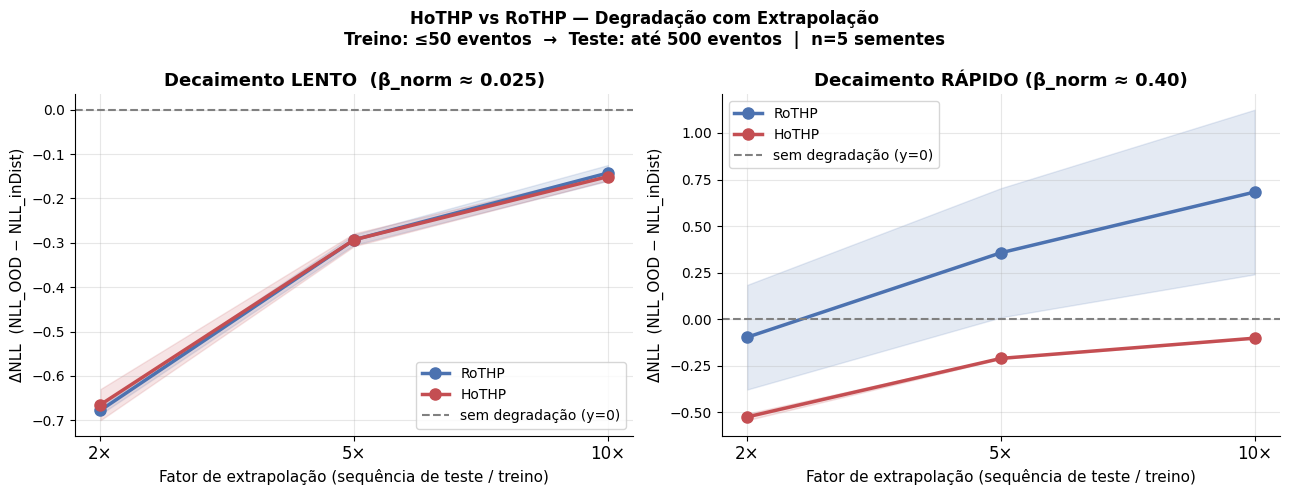

Gráfico salvo em: HoTHP_Resultado_Simplificado.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 6 — Gráfico principal: ΔNLL por fator de extrapolação
#
# O que é ΔNLL?
#   ΔNLL = NLL_OOD − NLL_inDist
#   → Se ΔNLL ≈ 0: o modelo extrapolou sem degradar
#   → Se ΔNLL > 0: o modelo piorou ao ver sequências mais longas
#   → Se ΔNLL < 0: o modelo até melhorou (inesperado, raro)
#
# HIPÓTESE: HoTHP (vermelho) deve ter ΔNLL menor que RoTHP (azul) no painel FAST.
# ─────────────────────────────────────────────────────────────────────────────

x = np.arange(len(EXTRAP_FACTORS))             # posições no eixo X
factor_labels = [f'{f}×' for f in EXTRAP_FACTORS]  # rótulos: '2×', '5×', '10×'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for col, (pname, proc) in enumerate(PROCESSES):
    sub = df[df['proc'] == pname]  # filtra resultados deste processo
    ax  = axes[col]

    for col_key, label, color in [
        ('r_deg', 'RoTHP', COR_ROTHP),
        ('h_deg', 'HoTHP', COR_HOTHP),
    ]:
        grp = sub.groupby('factor')[col_key]
        m   = grp.mean().reindex(EXTRAP_FACTORS)  # média sobre sementes
        s   = grp.std().reindex(EXTRAP_FACTORS)   # desvio padrão sobre sementes

        # Linha principal com pontos
        ax.plot(x, m.values, 'o-', color=color, lw=2.5, ms=8, label=label)
        # Faixa sombreada = ±1 desvio padrão
        ax.fill_between(x, m - s, m + s, color=color, alpha=0.15)

    # Linha de referência y=0: "sem piora" (modelo manteve qualidade)
    ax.axhline(0, color='gray', ls='--', lw=1.5, label='sem degradação (y=0)')

    ax.set_xticks(x)
    ax.set_xticklabels(factor_labels, fontsize=12)
    ax.set_xlabel('Fator de extrapolação (sequência de teste / treino)', fontsize=11)
    ax.set_ylabel('ΔNLL  (NLL_OOD − NLL_inDist)', fontsize=11)
    ax.set_title(proc['label'], fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    f'HoTHP vs RoTHP — Degradação com Extrapolação\n'
    f'Treino: ≤{TRAIN_LEN} eventos  →  Teste: até {TRAIN_LEN * max(EXTRAP_FACTORS)} eventos  |  n={N_SEEDS} sementes',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('HoTHP_Resultado_Simplificado.png', dpi=150, bbox_inches='tight')
plt.show()

print('Gráfico salvo em: HoTHP_Resultado_Simplificado.png')

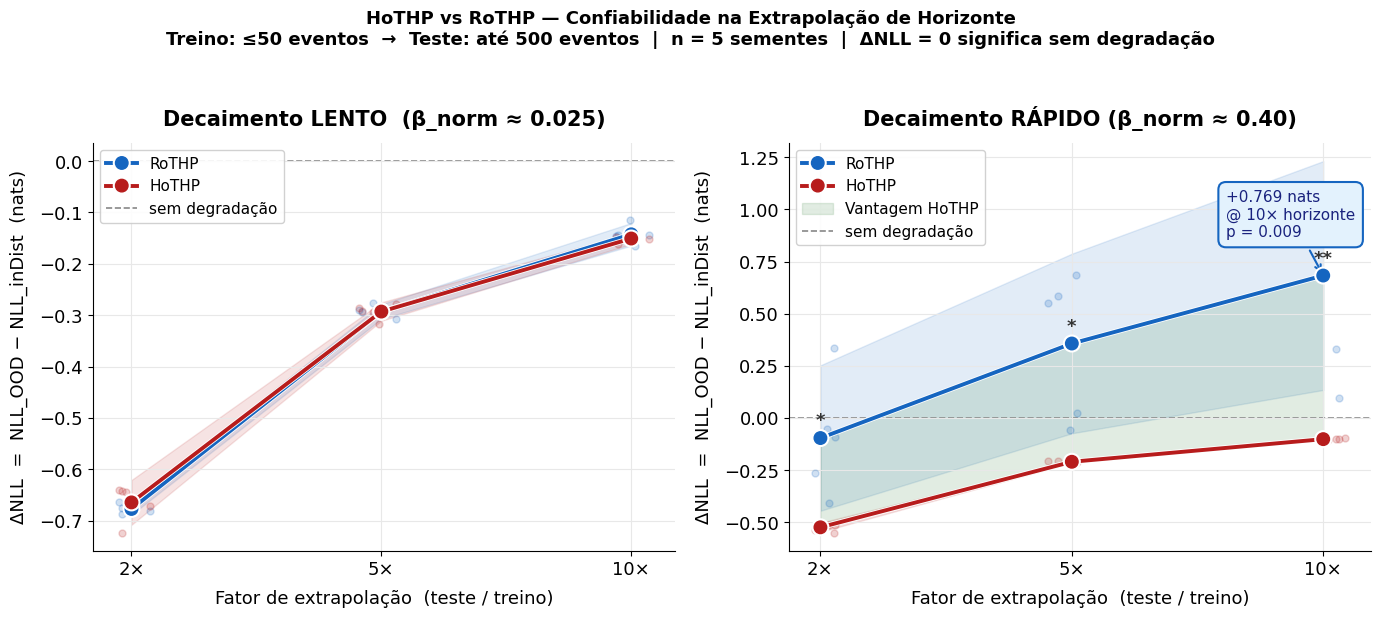

Gráfico de apresentação salvo em: HoTHP_Apresentacao.png


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 7 — Gráfico de apresentação (versão mais detalhada)
#
# Adiciona:
#   - Estrelas de significância estatística (*, **, ***)
#   - Dispersão por semente (pontinhos translúcidos)
#   - Zona verde "vantagem HoTHP" no painel RÁPIDO
#   - Caixa de destaque com o resultado principal no 10× do RÁPIDO
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.patheffects as pe

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         13,
    'axes.titlesize':    15,
    'axes.labelsize':    13,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e8e8e8',
    'grid.linewidth':    0.8,
})

C_RO    = '#1565C0'   # azul escuro para RoTHP
C_HO    = '#B71C1C'   # vermelho escuro para HoTHP
OUTLINE = [pe.withStroke(linewidth=4, foreground='white')]  # contorno branco nas linhas
XPOS    = np.arange(len(EXTRAP_FACTORS))


def sig_stars(adv_vals):
    """
    Calcula estrelas de significância estatística.
    Usa t-test unilateral: H0 = sem vantagem, H1 = HoTHP é melhor.
    ***  p < 0.001   (altamente significativo)
    **   p < 0.01
    *    p < 0.05    (significativo)
    ns   não significativo
    """
    t, p2 = stats.ttest_1samp(adv_vals, 0)
    p1 = p2 / 2 if t > 0 else 1.0  # unilateral: só conta se RoTHP > HoTHP
    if p1 < 0.001: return '***'
    if p1 < 0.01:  return '**'
    if p1 < 0.05:  return '*'
    return 'ns'


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.38)

TITULOS = {
    'slow': 'Decaimento LENTO  (β_norm ≈ 0.025)',
    'fast': 'Decaimento RÁPIDO (β_norm ≈ 0.40)',
}

for ax, (pname, proc) in zip(axes, PROCESSES):
    sub     = df[df['proc'] == pname]
    is_fast = (pname == 'fast')  # painel do RÁPIDO recebe elementos extras

    ro_means, ho_means = [], []
    ro_lows,  ho_lows  = [], []
    ro_highs, ho_highs = [], []

    for fi, f in enumerate(EXTRAP_FACTORS):
        rows     = sub[sub['factor'] == f]
        ro_delta = rows['r_deg'].values  # ΔNLL do RoTHP para este fator
        ho_delta = rows['h_deg'].values  # ΔNLL do HoTHP para este fator

        ro_means.append(ro_delta.mean())
        ho_means.append(ho_delta.mean())

        # Intervalo de confiança de 95% via t de Student
        for vals, lows, highs in [(ro_delta, ro_lows, ro_highs),
                                   (ho_delta, ho_lows, ho_highs)]:
            ci = stats.t.interval(0.95, len(vals) - 1,
                                  loc=vals.mean(),
                                  scale=stats.sem(vals))
            lows.append(ci[0])
            highs.append(ci[1])

        # Pontinhos individuais por semente (mostram a variabilidade real)
        jit = np.random.uniform(-0.10, 0.10, len(ro_delta))
        ax.scatter(fi + jit, ro_delta, color=C_RO, alpha=0.20, s=25, zorder=2)
        ax.scatter(fi + jit, ho_delta, color=C_HO, alpha=0.20, s=25, zorder=2)

    ro_means = np.array(ro_means)
    ho_means = np.array(ho_means)

    # Linhas principais com contorno branco (destaque visual)
    ax.plot(XPOS, ro_means, '-o', color=C_RO, lw=2.8, ms=9,
            label='RoTHP', zorder=5, path_effects=OUTLINE)
    ax.plot(XPOS, ho_means, '-o', color=C_HO, lw=2.8, ms=9,
            label='HoTHP', zorder=5, path_effects=OUTLINE)

    # Faixas de confiança
    ax.fill_between(XPOS, ro_lows, ro_highs, color=C_RO, alpha=0.12)
    ax.fill_between(XPOS, ho_lows, ho_highs, color=C_HO, alpha=0.12)

    # Zona verde: área onde RoTHP é pior que HoTHP (só no painel RÁPIDO)
    if is_fast:
        ax.fill_between(XPOS, ho_means, ro_means,
                        where=(ro_means > ho_means),
                        color='#2E7D32', alpha=0.14,
                        label='Vantagem HoTHP', interpolate=True)

    # Estrelas de significância acima do ponto mais alto de cada fator
    for fi, f in enumerate(EXTRAP_FACTORS):
        rows  = sub[sub['factor'] == f]
        stars = sig_stars(rows['adv'].values)
        if stars == 'ns':
            continue  # omite 'ns' para não poluir o gráfico
        top_y = max(ro_means[fi], ho_means[fi])
        ax.text(fi, top_y + 0.04, stars,
                ha='center', va='bottom', fontsize=13,
                fontweight='bold', color='#333')

    # Caixa de destaque com o resultado chave no horizonte 10× (só painel RÁPIDO)
    if is_fast:
        last_f  = EXTRAP_FACTORS[-1]
        rows    = sub[sub['factor'] == last_f]
        adv_mu  = rows['adv'].values.mean()  # vantagem média do HoTHP em nats
        t_, p2  = stats.ttest_1samp(rows['adv'].values, 0)
        p1      = p2 / 2 if t_ > 0 else 1.0
        p_str   = 'p < 0.001' if p1 < 0.001 else f'p = {p1:.3f}'
        label   = f'+{adv_mu:.3f} nats\n@ {last_f}× horizonte\n{p_str}'
        ax.annotate(
            label,
            xy=(XPOS[-1], ro_means[-1]),      # ponta da seta → pior resultado RoTHP
            xytext=(-70, 28), textcoords='offset points',
            fontsize=11, color='#1a237e',
            bbox=dict(boxstyle='round,pad=0.5', fc='#E3F2FD',
                      ec='#1565C0', lw=1.5),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1.5),
        )

    # Linha de referência y=0
    ax.axhline(0, color='#888', lw=1.2, ls='--', zorder=1, label='sem degradação')

    ax.set_xticks(XPOS)
    ax.set_xticklabels([f'{f}×' for f in EXTRAP_FACTORS])
    ax.set_xlabel('Fator de extrapolação  (teste / treino)', labelpad=8)
    ax.set_ylabel('ΔNLL  =  NLL_OOD − NLL_inDist  (nats)', labelpad=8)
    ax.set_title(TITULOS[pname], fontweight='bold', pad=12)
    ax.legend(loc='upper left', framealpha=0.9, fontsize=11)

fig.suptitle(
    'HoTHP vs RoTHP — Confiabilidade na Extrapolação de Horizonte\n'
    f'Treino: ≤{TRAIN_LEN} eventos  →  Teste: até {TRAIN_LEN * max(EXTRAP_FACTORS)} eventos'
    f'  |  n = {N_SEEDS} sementes  |  ΔNLL = 0 significa sem degradação',
    fontsize=13, fontweight='bold', y=1.03,
)

plt.tight_layout()
plt.savefig('HoTHP_Apresentacao.png', dpi=200, bbox_inches='tight')
plt.show()

print('Gráfico de apresentação salvo em: HoTHP_Apresentacao.png')

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CÉLULA 8 — Resumo numérico
# Imprime as NLLs OOD de cada modelo, a vantagem do HoTHP e a significância.
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 65)
print('RESUMO NUMÉRICO DOS RESULTADOS')
print('=' * 65)
print('NLL menor = modelo melhor.')
print('Vantagem = NLL_RoTHP_OOD - NLL_HoTHP_OOD  (positivo → HoTHP ganha)')

for pname, proc in PROCESSES:
    sub = df[df['proc'] == pname]
    print(f'\n{proc["label"]}')
    print(f'  {"Fator":>6}  {"NLL RoTHP":>11}  {"NLL HoTHP":>11}  '
          f'{"Vantagem":>11}  {"p":>7}  Sig')
    print(f'  {"-"*6}  {"-"*11}  {"-"*11}  {"-"*11}  {"-"*7}  ---')

    for f in EXTRAP_FACTORS:
        row = sub[sub['factor'] == f]
        rm  = row['r_ood'].mean(); rs = row['r_ood'].std()
        hm  = row['h_ood'].mean(); hs = row['h_ood'].std()
        adv = row['adv'].values

        # Teste t unilateral: HoTHP tem NLL menor que RoTHP?
        t_stat, p2 = stats.ttest_1samp(adv, 0)
        p1  = p2 / 2 if t_stat > 0 else 1 - p2 / 2

        # Notação de significância
        sig = ('***' if p1 < 0.001 else
               ('**'  if p1 < 0.01  else
               ('*'   if p1 < 0.05  else
               ('~'   if p1 < 0.10  else 'ns'))))

        print(f'  {f}×     {rm:.4f}±{rs:.3f}  {hm:.4f}±{hs:.3f}  '
              f'{adv.mean():>+.4f}±{adv.std():.3f}  p={p1:.3f}  {sig}')

print()
print('Legenda de significância:')
print('  *** p < 0.001  (altamente significativo)')
print('  **  p < 0.01')
print('  *   p < 0.05   (significativo)')
print('  ~   p < 0.10   (tendência)')
print('  ns  não significativo')

RESUMO NUMÉRICO DOS RESULTADOS
NLL menor = modelo melhor.
Vantagem = NLL_RoTHP_OOD - NLL_HoTHP_OOD  (positivo → HoTHP ganha)

Decaimento LENTO  (β_norm ≈ 0.025)
   Fator    NLL RoTHP    NLL HoTHP     Vantagem        p  Sig
  ------  -----------  -----------  -----------  -------  ---
  2×     1.0046±0.009  1.0309±0.021  -0.0263±0.014  p=0.990  ns
  5×     1.3890±0.011  1.4027±0.005  -0.0136±0.012  p=0.954  ns
  10×     1.5395±0.017  1.5449±0.018  -0.0054±0.024  p=0.664  ns

Decaimento RÁPIDO (β_norm ≈ 0.40)
   Fator    NLL RoTHP    NLL HoTHP     Vantagem        p  Sig
  ------  -----------  -----------  -----------  -------  ---
  2×     1.5829±0.281  1.1703±0.006  +0.4125±0.253  p=0.016  *
  5×     2.0360±0.347  1.4844±0.009  +0.5516±0.307  p=0.011  *
  10×     2.3619±0.442  1.5930±0.015  +0.7689±0.392  p=0.009  **

Legenda de significância:
  *** p < 0.001  (altamente significativo)
  **  p < 0.01
  *   p < 0.05   (significativo)
  ~   p < 0.10   (tendência)
  ns  não significativo


## Como interpretar os resultados?

### Leia os dois painéis do gráfico:

| Painel | Esperado | Por quê? |
|---|---|---|
| **Decaimento LENTO** | Ambos similares | A influência ainda se propaga além do horizonte de treino — ambos os modelos "acertam" por razões diferentes |
| **Decaimento RÁPIDO** | **HoTHP (vermelho) claramente abaixo** | A influência se dissipa rapidamente — o kernel hiperbólico do HoTHP captura exatamente esse comportamento de forma estrutural |

### O que o ΔNLL mede?
- `ΔNLL = NLL_OOD − NLL_inDist`
- Quanto mais próximo de **0**, melhor a extrapolação
- Linha tracejada em y=0 = "sem degradação"

### Por que o HoTHP tem vantagem no decaimento rápido?
O kernel hiperbólico do HoTHP é **matematicamente monotonicamente decrescente** com a distância temporal. Isso significa que o modelo aprende, durante o treino nas sequências curtas, uma estrutura de atenção que se generaliza naturalmente para sequências longas — sem precisar ter visto aqueles horizontes durante o treino.

O RoTHP usa embeddings rotativos (RoPE), que são ótimos para interpolação (comprimentos dentro da faixa de treino), mas não têm essa garantia de monotonicidade para extrapolação.